In [1]:
%run neural_simulation_functions.ipynb

Parameters.

In [3]:
num_neurons = 2
rate = 10 
time = 1000
num_samples = 100 # change to 100 to show Alex next time, but plot the first five trajectories or random five 
t0 = 200

In [4]:
# Simulation control parameters

# Network parameters
N_E = 1000
gamma = 0.25                    # ratio of inhibitory to excitatory neurons
N_I = round(gamma * N_E)
N = N_E + N_I
epsilon = 0.5                   # Sparsity of connections.  changed from 0.1, 0.2 was fine...
C_E = epsilon * N_E             # number of excitatory connections per neuron
C_ext = C_E                     # external connections per neuron


# Neuron parameters
tau = 20  * ms                  # Membrane time constant. previously 20, tried 50 it was weird, larger numbers more spikes, smaller numbers less spikes
                                # Higher Tau means slower decay, more spikes.
                                # Lower Tau means faster decay, fewer spikes
theta = 20  * mV                # spike threshold voltage, neuron fires when hitting this value
V_r = 10  * mV                  # reset potential, voltage neuron goes back to after firing
tau_rp = 2  * ms                # refractory period (neuron needs to wait some time before spiking again)

# Synapse parameters
J = 0.1 * mV                    # Synaptic strength # Previously 0.1 * mV, previouysly 0.075, 0.2 was too varied need to be more consistent
                                # larger J, stronger synaptic input, higher firing rate
                                # smaller J, weaker input, lower firing rates
D = 1.5  * ms                   # synaptic delay, time between a pre spike and its effect on postsynap neuron

# Simulation settings
dt = 0.1  * ms
g = 4                           # g is a good control for manipulating the firing rate, smaller numbers more spikes, bigger numbers less spikes
                                # Higher g, stronger inhibition, suppresses network activity
                                # Lower g, weaker inhibition, increase network activity
nu_ext_over_nu_thr = 1          # Previously 2, 1.2 was weird, 1 (made 2d plot nice), 0.5 not good,
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

nu_thr = theta / (J * C_E * tau) # minimal input rate needed to reach threshold
nu_ext = nu_ext_over_nu_thr * nu_thr # external input rate

# adjust g and nu_ext so that nu_ext is approximately the number of spikes that are occuring, influenced by g. 
# epsilon 0.2 and g = 2.6, g = 2.8 is too much,tau = 50
# epsilon 0.5 and g = 4, tau = 20

In [5]:
print(C_E) # C_E and C_ext are the same value

500.0


In [6]:
print(nu_thr)
print(nu_ext)

20. Hz
20. Hz


Generating spike trains, then counting the spikes.

In [8]:
raw_spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
print(raw_spike_train)

WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[{0: array([  9.7, 180.1, 449.6, 996. ]) * msecond, 1: array([0.0815, 0.1932, 0.2422, 0.2481, 0.3626, 0.592 , 0.6913, 0.7207]) * second}, {0: array([ 38.3, 120.8, 181. , 201.4, 469.3, 510.7, 939. , 999.1]) * msecond, 1: array([0.0384, 0.2003, 0.217 , 0.5044, 0.5222, 0.7065, 0.9054, 0.9844]) * second}, {0: array([0.1375, 0.2888, 0.334 , 0.3653, 0.3875, 0.4564, 0.5422, 0.7453]) * second, 1: array([0.1443, 0.261 , 0.476 , 0.6916, 0.7005, 0.7434, 0.782 , 0.8369,
       0.875 , 0.8868]) * second}, {0: array([0.0469, 0.174 , 0.1901, 0.2127, 0.3338, 0.7924, 0.9198, 0.946 ,
       0.9482]) * second, 1: array([ 11.3,  85.5, 179.9, 294.7, 479.9, 605.9, 686.1]) * msecond}, {0: array([ 66.2, 113.2, 155.4, 228. , 327.2, 418.7, 579.6, 621.3, 768.4,
       787.2]) * msecond, 1: array([0.0594, 0.0956, 0.1623, 0.2827, 0.2895, 0.52  , 0.5599, 0.7195,
       0.736 , 0.7977, 0.8204, 0.902 , 0.9518, 0.9707, 0.9874]) * second}, {0: array([0.0178, 0.0844, 0.1825, 0.3541, 0.3769, 0.4605, 0.4801, 0.5507,
     

In [9]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
print(loaded_spike_trains)

Spike trains saved to spike_trains.json
[{0: array([  9.7, 180.1, 449.6, 996. ]) * msecond, 1: array([0.0815, 0.1932, 0.2422, 0.2481, 0.3626, 0.592 , 0.6913, 0.7207]) * second}, {0: array([ 38.3, 120.8, 181. , 201.4, 469.3, 510.7, 939. , 999.1]) * msecond, 1: array([0.0384, 0.2003, 0.217 , 0.5044, 0.5222, 0.7065, 0.9054, 0.9844]) * second}, {0: array([0.1375, 0.2888, 0.334 , 0.3653, 0.3875, 0.4564, 0.5422, 0.7453]) * second, 1: array([0.1443, 0.261 , 0.476 , 0.6916, 0.7005, 0.7434, 0.782 , 0.8369,
       0.875 , 0.8868]) * second}, {0: array([0.0469, 0.174 , 0.1901, 0.2127, 0.3338, 0.7924, 0.9198, 0.946 ,
       0.9482]) * second, 1: array([ 11.3,  85.5, 179.9, 294.7, 479.9, 605.9, 686.1]) * msecond}, {0: array([ 66.2, 113.2, 155.4, 228. , 327.2, 418.7, 579.6, 621.3, 768.4,
       787.2]) * msecond, 1: array([0.0594, 0.0956, 0.1623, 0.2827, 0.2895, 0.52  , 0.5599, 0.7195,
       0.736 , 0.7977, 0.8204, 0.902 , 0.9518, 0.9707, 0.9874]) * second}, {0: array([0.0178, 0.0844, 0.1825, 0.354

In [10]:
spike_train = standardize_units(raw_spike_train)
print(spike_train)

[{0: array([0.0097, 0.1801, 0.4496, 0.996 ]), 1: array([0.0815, 0.1932, 0.2422, 0.2481, 0.3626, 0.592 , 0.6913, 0.7207])}, {0: array([0.0383, 0.1208, 0.181 , 0.2014, 0.4693, 0.5107, 0.939 , 0.9991]), 1: array([0.0384, 0.2003, 0.217 , 0.5044, 0.5222, 0.7065, 0.9054, 0.9844])}, {0: array([0.1375, 0.2888, 0.334 , 0.3653, 0.3875, 0.4564, 0.5422, 0.7453]), 1: array([0.1443, 0.261 , 0.476 , 0.6916, 0.7005, 0.7434, 0.782 , 0.8369,
       0.875 , 0.8868])}, {0: array([0.0469, 0.174 , 0.1901, 0.2127, 0.3338, 0.7924, 0.9198, 0.946 ,
       0.9482]), 1: array([0.0113, 0.0855, 0.1799, 0.2947, 0.4799, 0.6059, 0.6861])}, {0: array([0.0662, 0.1132, 0.1554, 0.228 , 0.3272, 0.4187, 0.5796, 0.6213,
       0.7684, 0.7872]), 1: array([0.0594, 0.0956, 0.1623, 0.2827, 0.2895, 0.52  , 0.5599, 0.7195,
       0.736 , 0.7977, 0.8204, 0.902 , 0.9518, 0.9707, 0.9874])}, {0: array([0.0178, 0.0844, 0.1825, 0.3541, 0.3769, 0.4605, 0.4801, 0.5507,
       0.5673, 0.6519, 0.68  , 0.7103, 0.7583, 0.8252, 0.8826, 0.912 ,

In [11]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
#print(binary_spikes[0][0])

In [12]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
# print(count)
print(count.shape)

(100, 2, 1000)


In [13]:
# Assuming `count` has shape (num_samples, neurons, time)
random_indices = np.random.choice(count.shape[0], size=5, replace=False)  # No duplicates
random_samples = count[random_indices]  # Shape: (5, neurons, time)

Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [15]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
print(raw_excitatory_spike_trains)

[{0: array([0.0531, 0.1006, 0.1748, 0.2523, 0.2913, 0.3939, 0.4416, 0.5557,
       0.6167, 0.6969, 0.7717, 0.8356, 0.8779, 0.9753]) * second, 1: array([0.054 , 0.1736, 0.2256, 0.2595, 0.3899, 0.4498, 0.6166, 0.6985,
       0.7729, 0.8344, 0.8779, 0.9137, 0.9562, 0.9753]) * second}, {0: array([0.0905, 0.1444, 0.2402, 0.3208, 0.3866, 0.4418, 0.5174, 0.6415,
       0.7042, 0.7991, 0.8787, 0.9259]) * second, 1: array([0.1031, 0.1745, 0.2222, 0.387 , 0.4841, 0.5175, 0.6289, 0.6779,
       0.7349, 0.7741, 0.8202, 0.8499, 0.9262]) * second}, {0: array([0.0789, 0.1907, 0.2298, 0.3452, 0.4493, 0.5226, 0.5635, 0.6145,
       0.6824, 0.7479, 0.8363, 0.889 , 0.9549]) * second, 1: array([0.0478, 0.1331, 0.1662, 0.2605, 0.3872, 0.5281, 0.5837, 0.6397,
       0.6839, 0.7183, 0.9712]) * second}, {0: array([0.0473, 0.1543, 0.3015, 0.3681, 0.4662, 0.5481, 0.6421, 0.7901,
       0.8261, 0.8624, 0.8965]) * second, 1: array([0.0496, 0.1876, 0.2823, 0.372 , 0.4532, 0.5165, 0.5496, 0.618 ,
       0.6584, 0.7

In [16]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [17]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

print(excitatory_spike_trains[0])
print(inhibitory_spike_trains[0])

{0: array([0.0531, 0.1006, 0.1748, 0.2523, 0.2913, 0.3939, 0.4416, 0.5557,
       0.6167, 0.6969, 0.7717, 0.8356, 0.8779, 0.9753]), 1: array([0.054 , 0.1736, 0.2256, 0.2595, 0.3899, 0.4498, 0.6166, 0.6985,
       0.7729, 0.8344, 0.8779, 0.9137, 0.9562, 0.9753])}
{0: array([0.0567, 0.1077, 0.1969, 0.2383, 0.3018, 0.3704, 0.4521, 0.5292,
       0.5593, 0.6181, 0.6517, 0.698 , 0.7596, 0.7771, 0.8321, 0.8773,
       0.9541]), 1: array([0.0494, 0.1451, 0.1943, 0.2399, 0.2998, 0.348 , 0.3877, 0.4501,
       0.5138, 0.56  , 0.6157, 0.6517, 0.6979, 0.761 , 0.7744, 0.8234,
       0.8791, 0.904 , 0.9722])}


In [18]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)

# print(binary_ex_spikes[0][0]) # first sample of first neuron

In [19]:
spike_count_ex = count_spikes(binary_ex_spikes)
#print(spike_count_ex[0])
count_ex = np.array(spike_count_ex)
print(count_ex[0])
print(count_ex[1])
print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
print(count_in.shape)

[[ 0.  0.  0. ... 14. 14. 14.]
 [ 0.  0.  0. ... 14. 14. 14.]]
[[ 0.  0.  0. ... 12. 12. 12.]
 [ 0.  0.  0. ... 13. 13. 13.]]
(100, 2, 1000)
(100, 2, 1000)


In [20]:
random_indices_ex = np.random.choice(count_ex.shape[0], size=5, replace=False)  # No duplicates
random_samples_ex = count_ex[random_indices_ex]  # Shape: (5, neurons, time)

random_indices_in = np.random.choice(count_in.shape[0], size=5, replace=False)  # No duplicates
random_samples_in = count_in[random_indices_in]  # Shape: (5, neurons, time)

Theoretical and Empirical stats of raw counts.

In [22]:
# empirical_mean = empirical_means(count) # np.mean(count, axis=0), count.mean(axis=0)
empirical_mean = count.mean(axis=0)
print(empirical_mean)
print(empirical_mean.shape)
count_rate = empirical_mean[:, -1]
print(count_rate)

# empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
empirical_std_dev = count.std(axis=0, ddof=1)
# empirical_std_dev = (count.std(axis=0)) #newly added, should be the same but isn't
# i fixed the above by using empirical_std_dev = (count.std(axis=0, ddof=1))
print(empirical_std_dev)
print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

[[0.02 0.02 0.02 ... 9.35 9.35 9.39]
 [0.02 0.03 0.03 ... 9.59 9.6  9.6 ]]
(2, 1000)
[9.39 9.6 ]
[[0.14070529 0.14070529 0.14070529 ... 3.23295843 3.23295843 3.22833103]
 [0.14070529 0.17144661 0.17144661 ... 3.33664987 3.33636226 3.33636226]]
(2, 1000)


In [23]:
theoretical_means = calculate_theoretical_mean(count_rate, time)
print(theoretical_means)
print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.00000e+00 9.39000e-03 1.87800e-02 ... 9.36183e+00 9.37122e+00
  9.38061e+00]
 [0.00000e+00 9.60000e-03 1.92000e-02 ... 9.57120e+00 9.58080e+00
  9.59040e+00]]
(2, 1000)
[[0.         0.09690201 0.13704014 ... 3.05971077 3.06124484 3.06277815]
 [0.         0.09797959 0.13856406 ... 3.09373561 3.09528674 3.0968371 ]]
(2, 1000)


In [24]:
hotelling_result = hotelling_t2_test(theoretical_means, empirical_mean)

In [25]:
res_var = variance_of_residuals(empirical_mean, theoretical_means)
print(res_var)

0.006100858698099056


Theoretical and Empirical stats of excitatory counts.

In [27]:
# empirical_mean_ex = empirical_means(count_ex)
empirical_mean_ex = count_ex.mean(axis=0)
print(empirical_mean_ex)
print(empirical_mean_ex.shape)
count_rate_ex = empirical_mean_ex[:, -1]

# empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
empirical_std_dev_ex = count_ex.std(axis=0, ddof=1)
print(empirical_std_dev_ex)
print(empirical_std_dev_ex.shape)

empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)

[[ 0.    0.    0.   ... 13.2  13.22 13.23]
 [ 0.    0.    0.   ... 13.79 13.82 13.84]]
(2, 1000)
[[0.         0.         0.         ... 1.51757382 1.53465029 1.53645926]
 [0.         0.         0.         ... 1.793901   1.81675702 1.79629248]]
(2, 1000)


In [28]:
theoretical_means_sim_ex = calculate_theoretical_mean(count_rate_ex, time)
print(theoretical_means_sim_ex)
print(theoretical_means_sim_ex.shape)

theoretical_std_dev_sim_ex = calculate_theoretical_std_dev(theoretical_means_sim_ex)
print(theoretical_std_dev_sim_ex)
print(theoretical_std_dev_sim_ex.shape)

theoretical_lower_bound_sim_ex, theoretical_upper_bound_sim_ex = confidence_intervals(theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.000000e+00 1.323000e-02 2.646000e-02 ... 1.319031e+01 1.320354e+01
  1.321677e+01]
 [0.000000e+00 1.384000e-02 2.768000e-02 ... 1.379848e+01 1.381232e+01
  1.382616e+01]]
(2, 1000)
[[0.         0.11502174 0.1626653  ... 3.63184664 3.63366757 3.63548759]
 [0.         0.11764353 0.16637307 ... 3.71463053 3.71649297 3.71835447]]
(2, 1000)


In [29]:
print(count_ex.std(axis=0))

[[0.         0.         0.         ... 1.50996689 1.52695776 1.52875767]
 [0.         0.         0.         ... 1.78490896 1.80765041 1.78728845]]


In [30]:
res_var_ex = variance_of_residuals(empirical_mean_ex, theoretical_means_sim_ex)
print(res_var_ex)

0.024641051944722353


Theoretical and Empirical stats of inhibitory counts.

In [32]:
# empirical_mean_in = empirical_means(count_in)
empirical_mean_in = count_in.mean(axis=0)
print(empirical_mean_in)
print(empirical_mean_in.shape)
count_rate_in = empirical_mean_in[:, -1]

#empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
empirical_std_dev_in = count_in.std(axis=0, ddof=1)
print(empirical_std_dev_in)
print(empirical_std_dev_in.shape)

empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)

[[ 0.    0.    0.   ... 19.89 19.91 19.94]
 [ 0.    0.    0.   ... 20.16 20.19 20.22]]
(2, 1000)
[[0.         0.         0.         ... 1.52351932 1.51153812 1.50299365]
 [0.         0.         0.         ... 1.75648869 1.75634492 1.77285936]]
(2, 1000)


In [33]:
theoretical_means_sim_in = calculate_theoretical_mean(count_rate_in, time)
print(theoretical_means_sim_in)
print(theoretical_means_sim_in.shape)

theoretical_std_dev_sim_in = calculate_theoretical_std_dev(theoretical_means_sim_in)
print(theoretical_std_dev_sim_in)
print(theoretical_std_dev_sim_in.shape)

theoretical_lower_bound_sim_in, theoretical_upper_bound_sim_in = confidence_intervals(theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.000000e+00 1.994000e-02 3.988000e-02 ... 1.988018e+01 1.990012e+01
  1.992006e+01]
 [0.000000e+00 2.022000e-02 4.044000e-02 ... 2.015934e+01 2.017956e+01
  2.019978e+01]]
(2, 1000)
[[0.         0.14120906 0.19969977 ... 4.45871955 4.46095505 4.46318944]
 [0.         0.14219705 0.20109699 ... 4.48991537 4.49216652 4.49441654]]
(2, 1000)


In [34]:
res_var_in = variance_of_residuals(empirical_mean_in, theoretical_means_sim_in)
print(res_var_in)

0.0493257346673337


Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

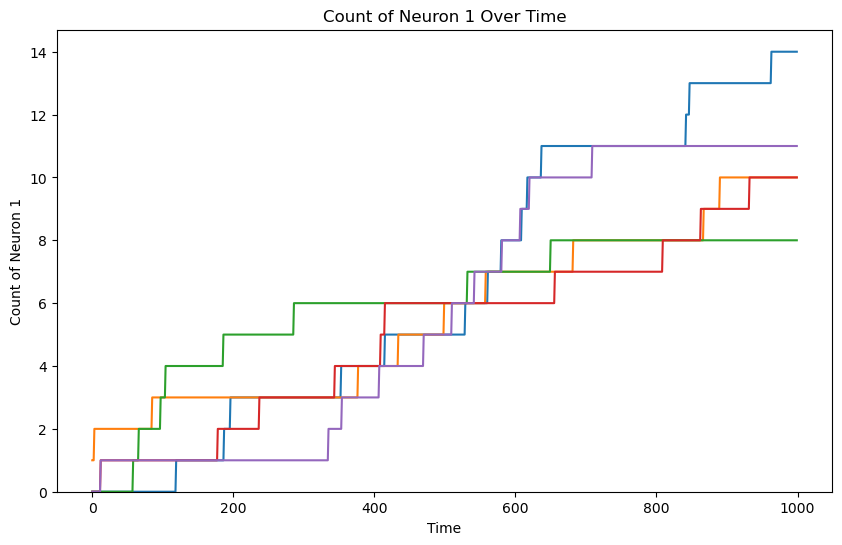

In [36]:
plot_count_neuron1_vs_time(random_samples, num_samples = 5)
# plot_count_neuron1_vs_time(count, num_samples)

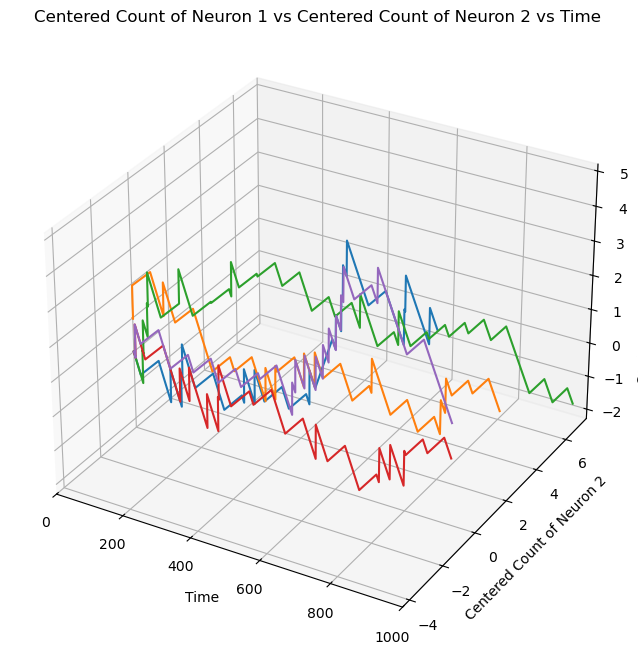

In [37]:
plot_centered_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, num_samples=5)
# plot_centered_staircase_3d(count, theoretical_means, theoretical_std_dev, num_samples)

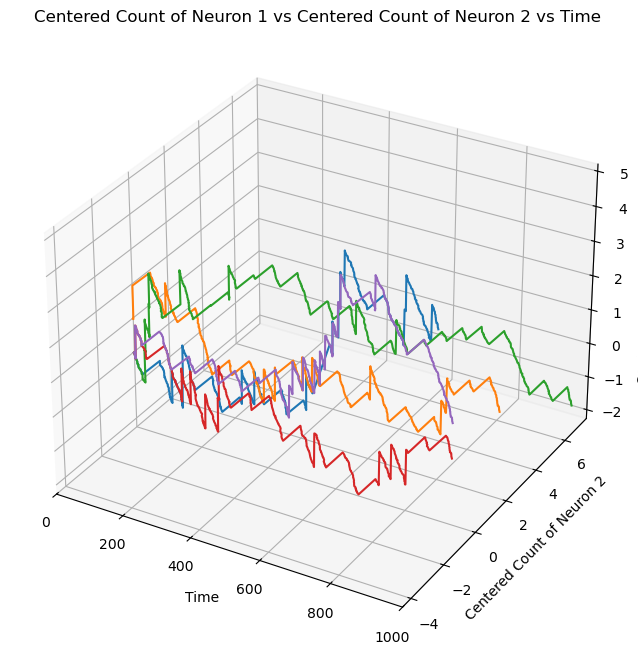

In [38]:
plot_centered_staircase_3d(random_samples, empirical_mean, empirical_std_dev, num_samples= 5)
# plot_centered_staircase_3d(count, empirical_mean, empirical_std_dev, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:8: RuntimeWarning: divide by zero encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]


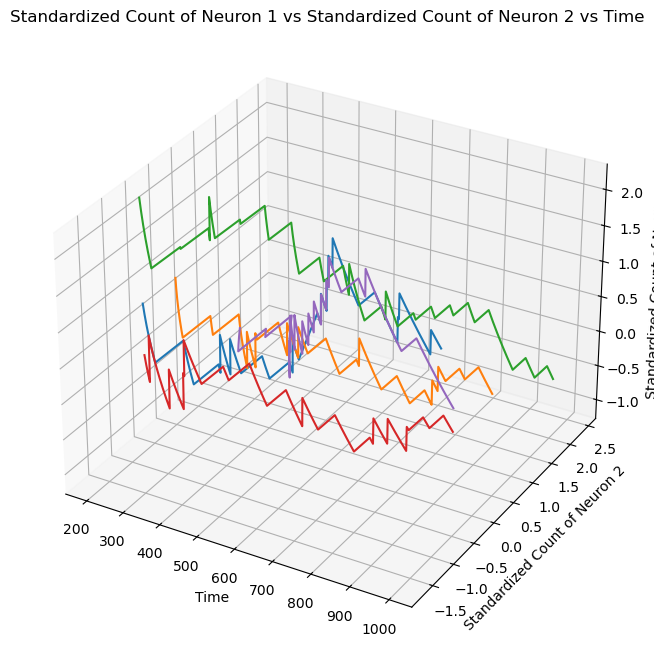

In [39]:
plot_standardized_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, t0, num_samples=5)
# plot_standardized_staircase_3d(count, theoretical_means, theoretical_std_dev, t0, num_samples)

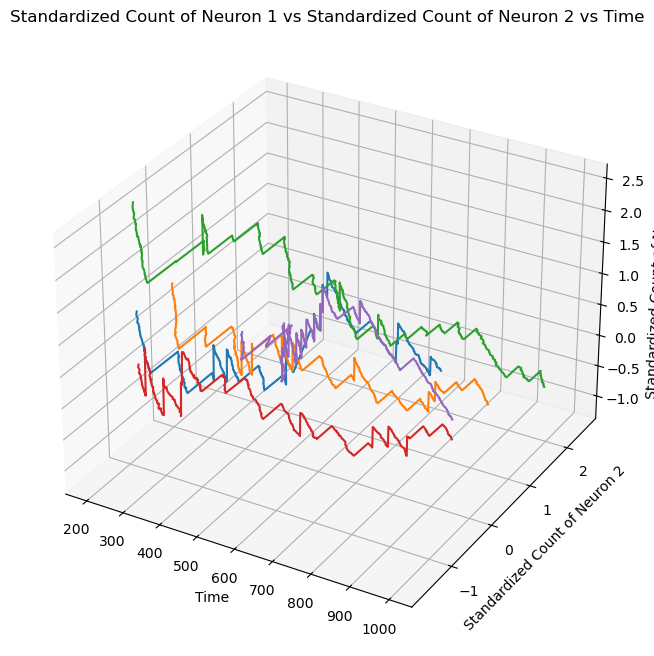

In [40]:
plot_standardized_staircase_3d(random_samples, empirical_mean, empirical_std_dev, t0, num_samples=5)
# plot_standardized_staircase_3d(count, empirical_mean, empirical_std_dev, t0, num_samples)

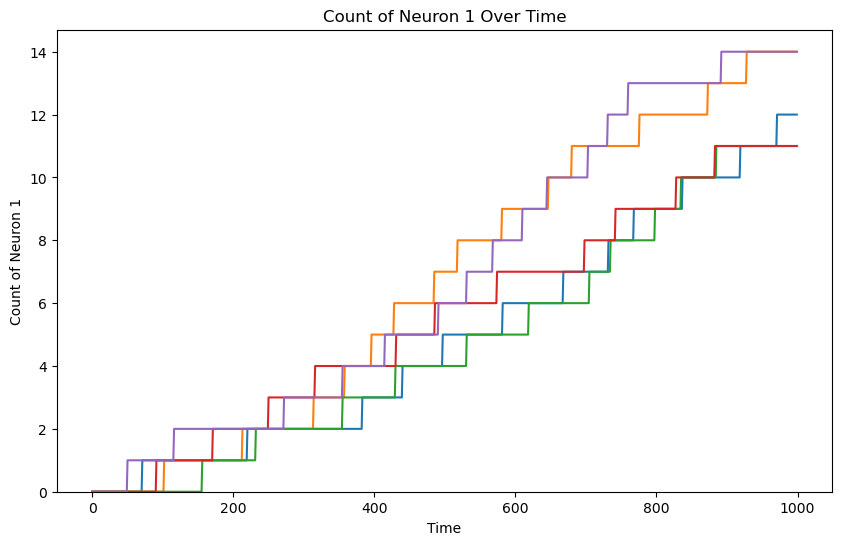

In [41]:
plot_count_neuron1_vs_time(random_samples_ex, num_samples = 5)
# plot_count_neuron1_vs_time(count_ex, num_samples)

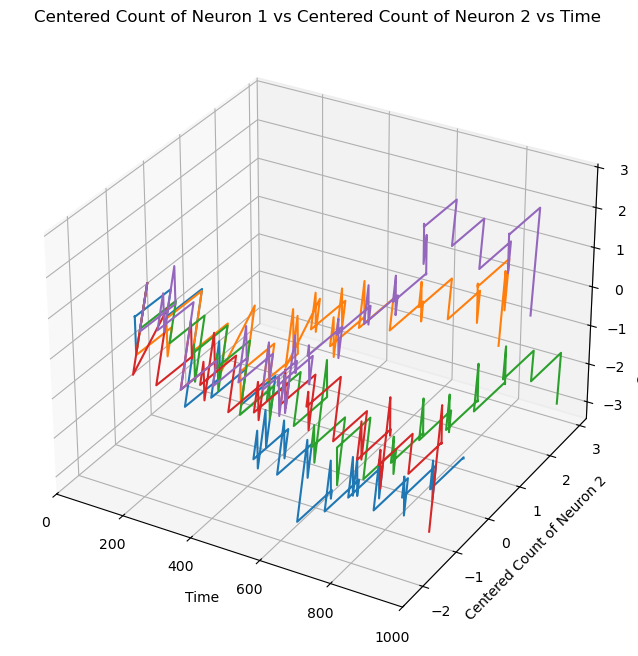

In [42]:
plot_centered_staircase_3d(random_samples_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples= 5)
# plot_centered_staircase_3d(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples)

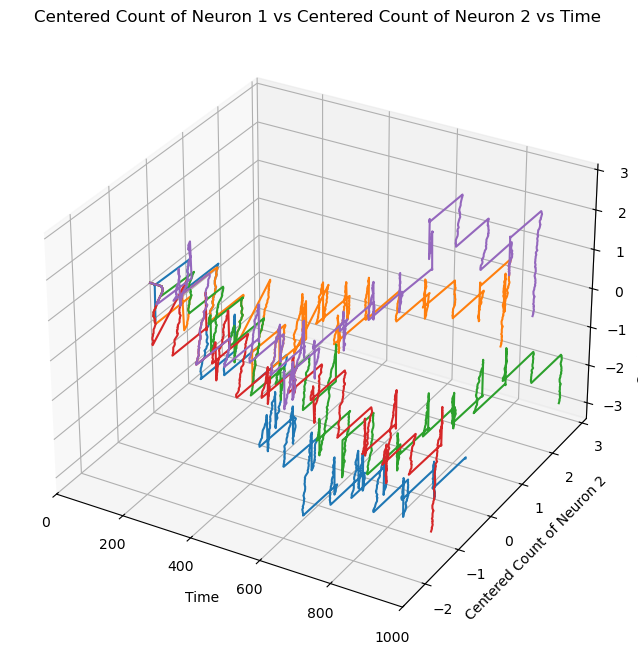

In [43]:
plot_centered_staircase_3d(random_samples_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples= 5)
# plot_centered_staircase_3d(count_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


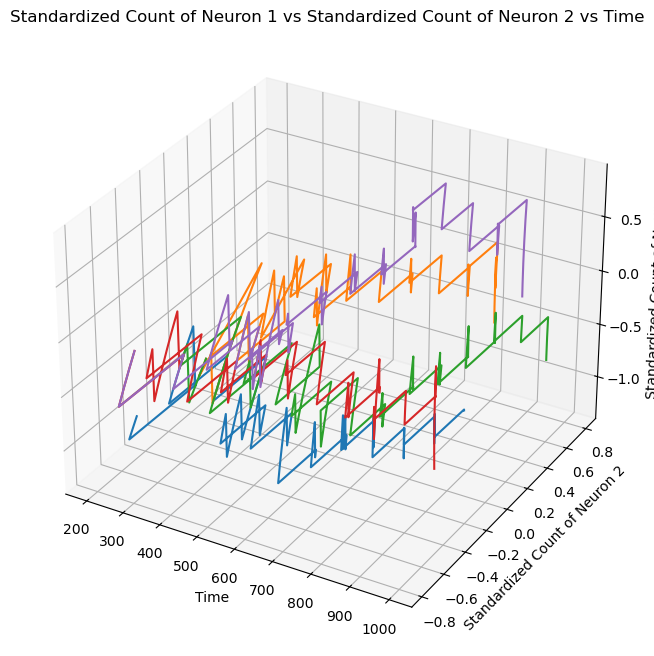

In [44]:
plot_standardized_staircase_3d(random_samples_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, t0, num_samples=5)
# plot_standardized_staircase_3d(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, t0, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


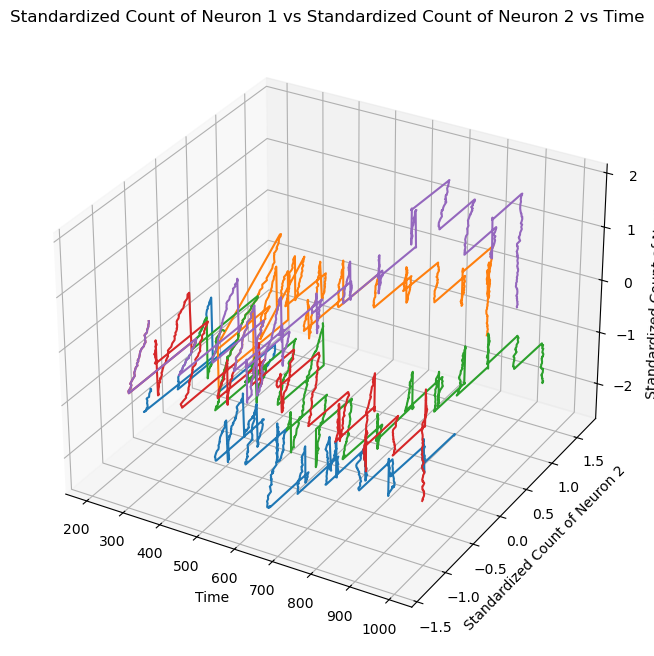

In [45]:
plot_standardized_staircase_3d(random_samples_ex, empirical_mean_ex, empirical_std_dev_ex, t0, num_samples=5)
# plot_standardized_staircase_3d(rcount_ex, empirical_mean_ex, empirical_std_dev_ex, t0, num_samples)

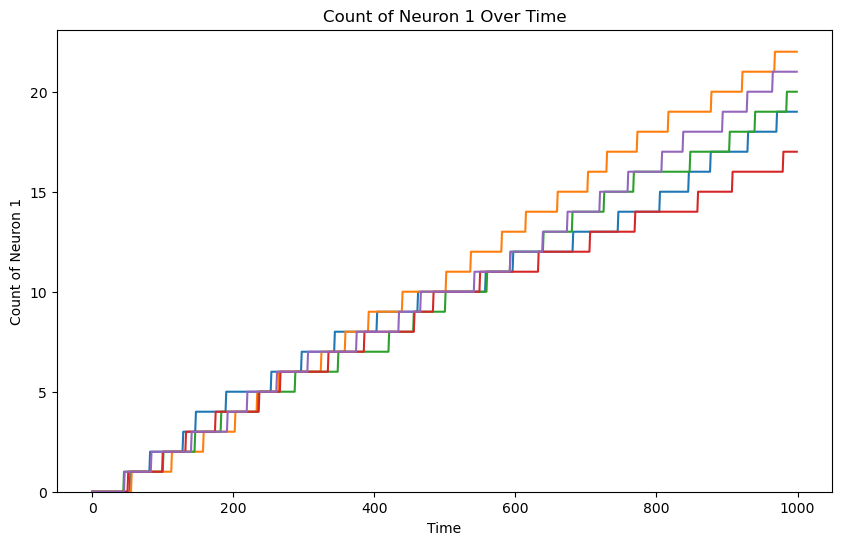

In [46]:
plot_count_neuron1_vs_time(random_samples_in, num_samples = 5)
# plot_count_neuron1_vs_time(count_in, num_samples)

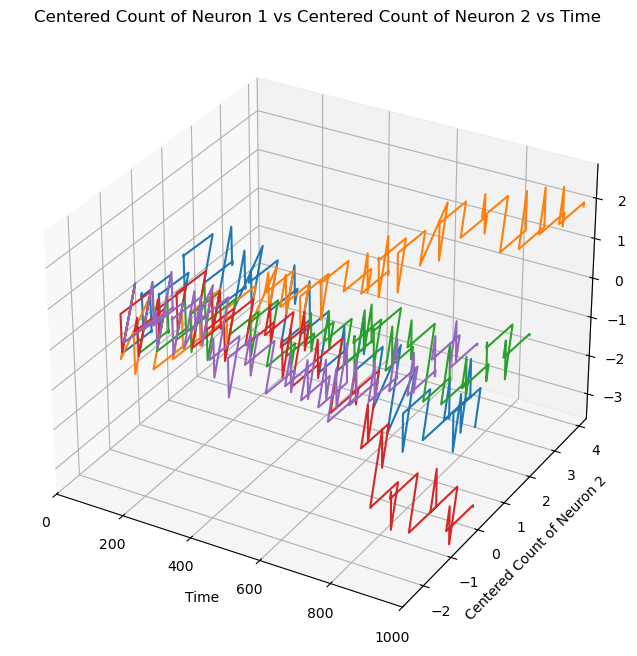

In [47]:
plot_centered_staircase_3d(random_samples_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples= 5)
# plot_centered_staircase_3d(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples)

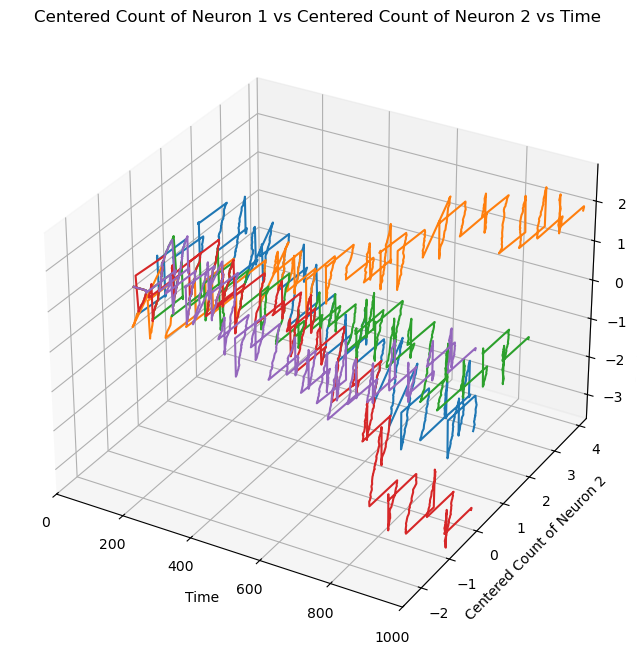

In [48]:
plot_centered_staircase_3d(random_samples_in, empirical_mean_in, empirical_std_dev_in, num_samples= 5)
# plot_centered_staircase_3d(count_in, empirical_mean_in, empirical_std_dev_in, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


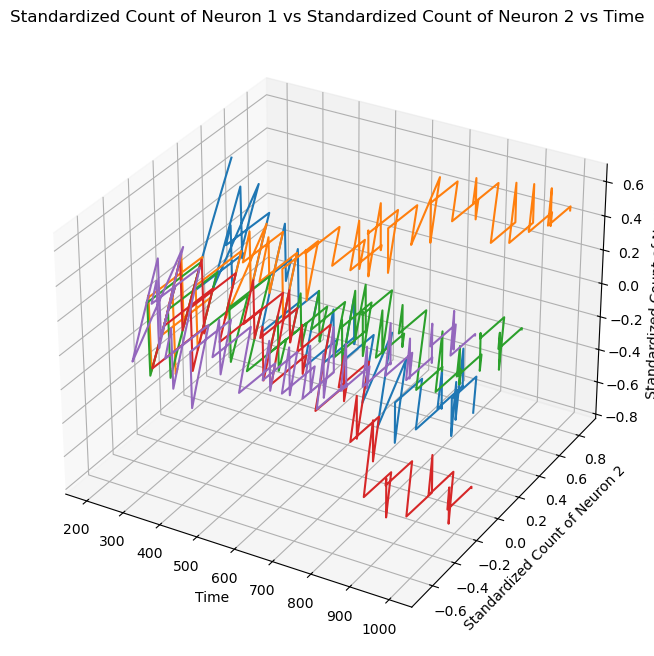

In [49]:
plot_standardized_staircase_3d(random_samples_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, t0, num_samples=5)
# plot_standardized_staircase_3d(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, t0, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_3712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


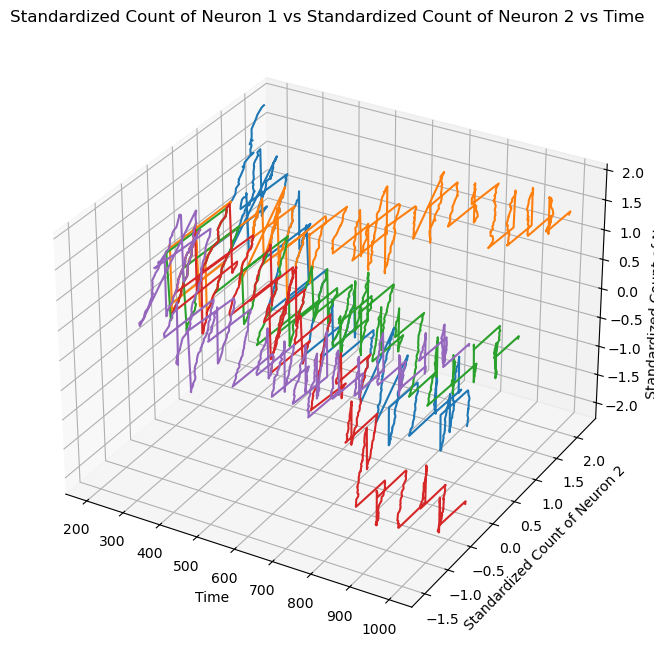

In [50]:
plot_standardized_staircase_3d(random_samples_in, empirical_mean_in, empirical_std_dev_in, t0, num_samples=5)
# plot_standardized_staircase_3d(count_in, empirical_mean_in, empirical_std_dev_in, t0, num_samples)